# 09 - Risk Decisioning and Monitoring

## Credit Risk Modelling Using Logistic Regression

This notebook applies the saved Notebook 08 champion model to risk bands, illustrative decisions, expected-loss examples, explanations, and monitoring metrics. The champion remains fixed; this notebook does not reselect or tune it.

The data provide default labels and borrower characteristics, but no lending economics, temporal validation sample, or production population. Decision thresholds and LGD/EAD examples are therefore explicitly illustrative. The random holdout is an internal comparison sample, not production drift data.


## 1. Load the champion and reproduce the common split

The final model package stores the selected estimator and calibration mapping. Reference predictions for the training population are regenerated out of fold, so population comparisons do not rely on in-sample fitted PDs. The seed 47 holdout remains the current internal comparison sample.


In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.metrics import roc_auc_score, brier_score_loss

sys.path.insert(0, "../src")
from model import prepare_data, split_data
from model_comparison import cross_preds, predict_candidate
from scorecard import score_rows
from monitoring import (
    RISK_LABS, quant_edges, risk_band, decision_band,
    psi_num, psi_cat, psi_status, expected_loss,
)
from evaluation import discrimination_metrics, calibration_table

clean = pd.read_csv("../data/processed/cleaned_data.csv")
feat, target = prepare_data(clean)
with open("../models/logistic_regression.pkl", "rb") as model_file:
    base_pack = pickle.load(model_file)
with open("../models/final_model.pkl", "rb") as model_file:
    final_pack = pickle.load(model_file)
with open("../models/scorecard_model.pkl", "rb") as model_file:
    score_pack = pickle.load(model_file)

train_feat, hold_feat, train_y, hold_y = split_data(
    feat, target, base_pack["seed"]
)
SEED = base_pack["seed"]
champ = final_pack["model_id"]
train_oof = cross_preds(train_feat, train_y, seed=SEED, n_splits=5)
ref_pd = train_oof[champ]
hold_pd = predict_candidate(hold_feat, final_pack)
print(f"Champion: {champ}")
print(f"Seed: {SEED}")
print(f"Training OOF rows: {len(ref_pd):,}")
print(f"Holdout rows: {len(hold_pd):,}")


Champion: boost
Seed: 47
Training OOF rows: 101,893
Holdout rows: 43,669


## 2. PD risk bands

Create five bands from quintiles of the champion's training OOF PDs, then apply the fixed cut points to the holdout. These groups describe relative risk in this sample, not approved lending grades. Check observed bad rates for an increasing pattern.


In [2]:
band_edges = quant_edges(ref_pd, n_bins=5)
ref_band = risk_band(ref_pd, band_edges)
hold_band = risk_band(hold_pd, band_edges)

band_data = pd.DataFrame({
    "band": hold_band,
    "target": hold_y,
    "pred_pd": hold_pd,
})
band_tab = band_data.groupby("band", observed=False, sort=True).agg(
    borrowers=("target", "size"),
    mean_pd=("pred_pd", "mean"),
    bads=("target", "sum"),
    bad_rate=("target", "mean"),
).reset_index()
display(band_tab.round(4))
band_rate = band_tab["bad_rate"].dropna().to_numpy()
mono_ok = bool((np.diff(band_rate) >= 0).all())
print("Observed bad rate increases across bands:", mono_ok)
print("Training-derived band edges:", np.round(band_edges, 6).tolist())


,band,borrowers,mean_pd,bads,bad_rate
0,Very Low,9453,0.0064,47,0.0050
1,Low,8609,0.0113,99,0.0115
2,Medium,7791,0.0223,199,0.0255
3,High,8892,0.0544,468,0.0526
4,Very High,8924,0.2394,2136,0.2394


Observed bad rate increases across bands: True
Training-derived band edges: [-inf, 0.00867, 0.014618, 0.033644, 0.083341, inf]


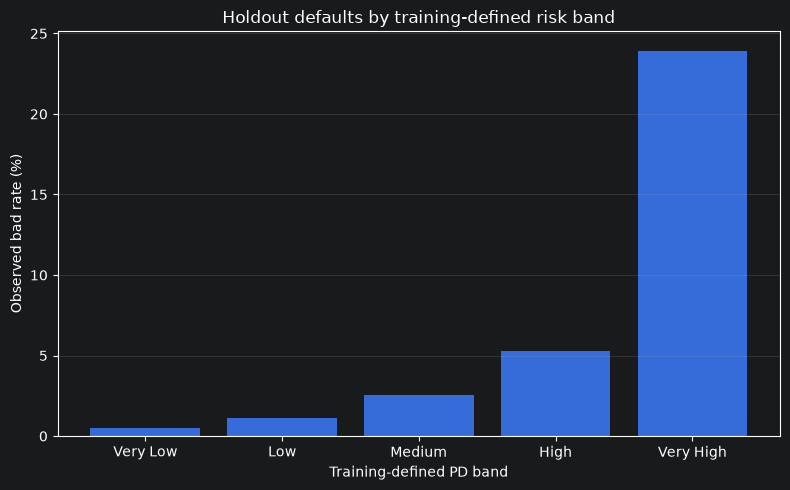

Saved risk-band chart to ../reports/figures/09_risk_bands.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(band_tab["band"].astype(str), band_tab["bad_rate"] * 100)
ax.set_xlabel("Training-defined PD band")
ax.set_ylabel("Observed bad rate (%)")
ax.set_title("Holdout defaults by training-defined risk band")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
BAND_PATH = "../reports/figures/09_risk_bands.png"
fig.savefig(BAND_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved risk-band chart to {BAND_PATH}")


## 3. Illustrative decision thresholds

For demonstration, set approval and rejection cutoffs at the 60th and 85th percentiles of training OOF PD. This creates approximate 60% approve, 25% review, and 15% reject shares in the reference sample. The cutoffs are illustrative capacity splits, not credit policy or economically optimized thresholds.


In [4]:
cut_a, cut_b = np.quantile(ref_pd, [0.60, 0.85])
hold_dec = decision_band(hold_pd, cut_a, cut_b)
dec_order = pd.Categorical(
    hold_dec, categories=["Approve", "Review", "Reject"], ordered=True
)
dec_data = pd.DataFrame({
    "decision": dec_order,
    "target": hold_y,
    "pred_pd": hold_pd,
})
dec_tab = dec_data.groupby("decision", observed=False, sort=True).agg(
    borrowers=("target", "size"),
    mean_pd=("pred_pd", "mean"),
    bads=("target", "sum"),
    bad_rate=("target", "mean"),
).reset_index()
dec_tab["share"] = dec_tab["borrowers"] / len(hold_y)
display(dec_tab.round(4))
print(f"Illustrative approve cutoff: PD < {cut_a:.4%}")
print(f"Illustrative reject cutoff: PD >= {cut_b:.4%}")


,decision,borrowers,mean_pd,bads,bad_rate,share
0,Approve,25853,0.0128,345,0.0133,0.592
1,Review,11136,0.0631,711,0.0638,0.255
2,Reject,6680,0.2871,1893,0.2834,0.153


Illustrative approve cutoff: PD < 3.3644%
Illustrative reject cutoff: PD >= 11.7078%


## 4. Expected Loss under hypothetical assumptions

Expected loss is

$$
EL=PD	imes LGD	imes EAD.
$$

PD is estimated by the model. The dataset does not contain LGD or EAD, so the following calculations use explicit hypothetical assumptions in generic currency units. They are examples only and are not project estimates or underwriting economics.


In [5]:
loss_pd = np.array([0.02, 0.05, 0.15, 0.30])
loss_lgd = 0.45
loss_ead = 10000.0
loss_tab = pd.DataFrame({
    "hypothetical_pd": loss_pd,
    "assumed_lgd": loss_lgd,
    "assumed_ead_units": loss_ead,
    "expected_loss_units": expected_loss(loss_pd, loss_lgd, loss_ead),
})
display(loss_tab.round(2))
print("Assumptions: LGD=45%, EAD=10,000 generic currency units per example.")


,hypothetical_pd,assumed_lgd,assumed_ead_units,expected_loss_units
0,0.02,0.45,10000.0,90.0
1,0.05,0.45,10000.0,225.0
2,0.15,0.45,10000.0,675.0
3,0.30,0.45,10000.0,1350.0


Assumptions: LGD=45%, EAD=10,000 generic currency units per example.


## 5. Explainability

The champion is Gradient Boosting, so logistic odds ratios are not its explanation method. Use repeated holdout permutation to estimate global importance: how much AUC falls and Brier score rises when one feature is shuffled. This is descriptive, can split importance across correlated predictors, and does not imply causation.


In [6]:
feat_lab = {
    "age": "Age",
    "RevolvingUtilizationOfUnsecuredLines": "Revolving utilization",
    "DebtRatio": "Debt ratio",
    "LogMonthlyIncome": "Log monthly income",
    "TotalDelinquencies": "Total delinquencies",
    "NumberOfOpenCreditLinesAndLoans": "Open credit lines",
    "NumberRealEstateLoansOrLines": "Real estate loans",
    "NumberOfDependents": "Dependents",
}
base_auc = roc_auc_score(hold_y, hold_pd)
base_br = brier_score_loss(hold_y, hold_pd)
imp_rows = []
for pos, col in enumerate(hold_feat.columns):
    auc_loss = []
    br_rise = []
    rng = np.random.default_rng(SEED + pos)
    for rep in range(5):
        perm = hold_feat.copy()
        perm[col] = rng.permutation(perm[col].to_numpy())
        pred = predict_candidate(perm, final_pack)
        auc_loss.append(base_auc - roc_auc_score(hold_y, pred))
        br_rise.append(brier_score_loss(hold_y, pred) - base_br)
    imp_rows.append({
        "feature": feat_lab[col],
        "auc_drop": float(np.mean(auc_loss)),
        "brier_rise": float(np.mean(br_rise)),
        "auc_sd": float(np.std(auc_loss, ddof=1)),
    })
imp_tab = pd.DataFrame(imp_rows).sort_values(
    "auc_drop", ascending=False
).reset_index(drop=True)
display(imp_tab.round(5))


,feature,auc_drop,brier_rise,auc_sd
0,Total delinquencies,0.12041,0.01295,0.00232
1,Revolving utilization,0.07543,0.00411,0.00262
2,Age,0.00961,0.00053,0.00059
3,Open credit lines,0.00534,0.00053,0.00099
4,Debt ratio,0.00501,0.00049,0.00043
5,Real estate loans,0.00428,0.00029,0.00045
6,Log monthly income,0.00307,0.00027,0.00048
7,Dependents,0.00036,0.00003,0.00018


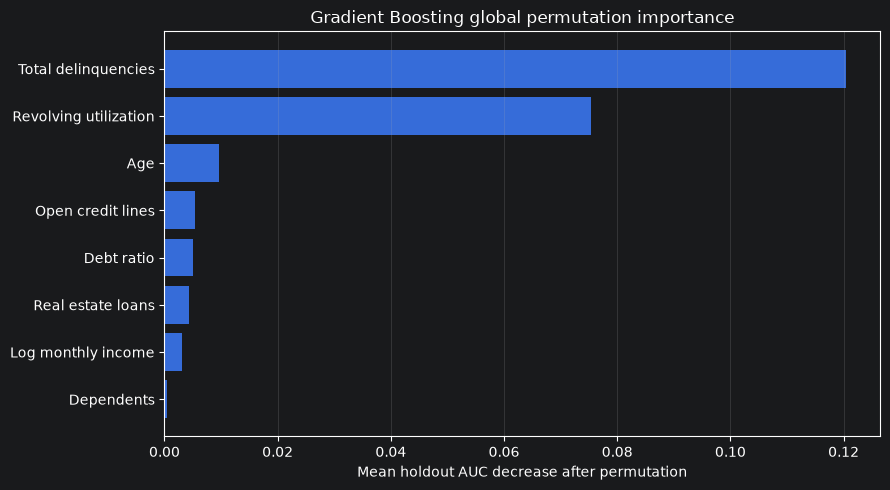

Saved importance chart to ../reports/figures/09_permutation_importance.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_imp = imp_tab.sort_values("auc_drop")
ax.barh(plot_imp["feature"], plot_imp["auc_drop"])
ax.set_xlabel("Mean holdout AUC decrease after permutation")
ax.set_title("Gradient Boosting global permutation importance")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
IMP_PATH = "../reports/figures/09_permutation_importance.png"
fig.savefig(IMP_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved importance chart to {IMP_PATH}")


### Local sensitivity examples

Select three holdout borrowers near the 10th, 50th, and 90th PD percentiles. For each one, replace one important feature at a time with its training median and recompute PD. This is a simple sensitivity check, not a causal or additive explanation; a median replacement can create an unrealistic borrower profile, and feature interactions remain in the model.


In [8]:
top_cols = [
    col for col in imp_tab["feature"].head(3)
]
col_map = {feat_lab[key]: key for key in feat_lab}
case_q = {"Lower-risk example": 0.10, "Middle example": 0.50, "Higher-risk example": 0.90}
case_idx = {}
case_rows = []
for name, quant in case_q.items():
    goal = hold_pd.quantile(quant)
    idx = (hold_pd - goal).abs().idxmin()
    case_idx[name] = idx
    row = {"example": name, "predicted_pd": hold_pd.loc[idx]}
    row["risk_band"] = str(hold_band.loc[idx])
    for label in top_cols:
        col = col_map[label]
        row[label] = hold_feat.loc[idx, col]
    case_rows.append(row)
case_tab = pd.DataFrame(case_rows)
display(case_tab.round(4))

sens_rows = []
for name, idx in case_idx.items():
    for label in top_cols:
        col = col_map[label]
        one = hold_feat.loc[[idx]].copy()
        med = train_feat[col].median()
        one[col] = med
        new_pd = float(predict_candidate(one, final_pack).iloc[0])
        sens_rows.append({
            "example": name,
            "feature": label,
            "observed_value": hold_feat.loc[idx, col],
            "train_median": med,
            "pd_after_change": new_pd,
            "pd_change": new_pd - hold_pd.loc[idx],
        })
sens_tab = pd.DataFrame(sens_rows)
display(sens_tab.round(4))


,example,predicted_pd,risk_band,Total delinquencies,Revolving utilization,Age
0,Lower-risk example,0.0063,Very Low,0,0.0013,32
1,Middle example,0.0209,Medium,0,0.2120,44
2,Higher-risk example,0.1824,Very High,3,0.1570,29


,example,feature,observed_value,train_median,pd_after_change,pd_change
0,Lower-risk example,Total delinquencies,0.0000,0.0000,0.0063,0.0000
1,Lower-risk example,Revolving utilization,0.0013,0.1586,0.0119,0.0056
2,Lower-risk example,Age,32.0000,52.0000,0.0058,-0.0004
3,Middle example,Total delinquencies,0.0000,0.0000,0.0209,0.0000
4,Middle example,Revolving utilization,0.2120,0.1586,0.0185,-0.0024
5,Middle example,Age,44.0000,52.0000,0.0206,-0.0003
6,Higher-risk example,Total delinquencies,3.0000,0.0000,0.0239,-0.1585
7,Higher-risk example,Revolving utilization,0.1570,0.1586,0.1824,0.0000
8,Higher-risk example,Age,29.0000,52.0000,0.1650,-0.0174


## 6. Population Stability Index

PSI compares a reference distribution with a current comparison distribution:

$$
PSI=\sum_i(P_i-Q_i)\ln\left(\frac{P_i}{Q_i}\right).
$$

Use training OOF predictions as the reference and the random holdout as the comparison. Numeric cut points come from the reference distribution; 0.5-count smoothing avoids undefined terms. Common PSI bands (<0.10, 0.10-0.25, >0.25) are included as rough monitoring heuristics, not universal thresholds.

This random split is not a time-based production sample. The resulting PSI values illustrate the calculation only and cannot establish production stability or drift.


In [9]:
from advanced_model import short_frame, cal_gap

ref_x = short_frame(train_feat)
cur_x = short_frame(hold_feat)
watch_cols = ["util", "delinq", "age", "debt", "income"]
watch_lab = {"util": "Revolving utilization", "delinq": "Total delinquencies", "age": "Age", "debt": "Debt ratio", "income": "Log monthly income"}
psi_rows = []
for col in watch_cols:
    edges = quant_edges(ref_x[col], n_bins=10)
    value = psi_num(ref_x[col], cur_x[col], edges)
    psi_rows.append({
        "population": watch_lab[col],
        "psi": value,
        "status": psi_status(value),
    })

pd_edges = quant_edges(ref_pd, n_bins=10)
pd_psi = psi_num(ref_pd, hold_pd, pd_edges)
band_psi = psi_cat(ref_band, hold_band, RISK_LABS)
score_ref = score_rows(train_feat, score_pack)["score"]
score_cur = score_rows(hold_feat, score_pack)["score"]
score_edges = quant_edges(score_ref, n_bins=10)
score_psi = psi_num(score_ref, score_cur, score_edges)
psi_rows.extend([
    {"population": "Champion predicted PD", "psi": pd_psi, "status": psi_status(pd_psi)},
    {"population": "Champion risk band", "psi": band_psi, "status": psi_status(band_psi)},
    {"population": "WoE scorecard score", "psi": score_psi, "status": psi_status(score_psi)},
])
psi_tab = pd.DataFrame(psi_rows).sort_values("psi", ascending=False)
display(psi_tab.round(4))
print("Score PSI is for the Notebook 07 scorecard candidate; the champion is Gradient Boosting.")


,population,psi,status
5,Champion predicted PD,0.0053,Low shift
6,Champion risk band,0.0040,Low shift
7,WoE scorecard score,0.0005,Low shift
2,Age,0.0002,Low shift
4,Log monthly income,0.0002,Low shift
0,Revolving utilization,0.0001,Low shift
3,Debt ratio,0.0001,Low shift
1,Total delinquencies,0.0000,Low shift


Score PSI is for the Notebook 07 scorecard candidate; the champion is Gradient Boosting.


## 7. Performance monitoring summary

The table contrasts training OOF reference metrics with the internal holdout. It contains no production measurements. A real monitoring process would compare time-stamped application and outcome data after an appropriate performance-observation window.


In [10]:
ref_met = discrimination_metrics(train_y, ref_pd)
cur_met = discrimination_metrics(hold_y, hold_pd)
perf_rows = [
    {"metric": "AUC", "current": cur_met["roc_auc"], "reference": ref_met["roc_auc"], "status": "Internal split"},
    {"metric": "KS", "current": cur_met["ks"], "reference": ref_met["ks"], "status": "Internal split"},
    {"metric": "Brier", "current": cur_met["brier_score"], "reference": ref_met["brier_score"], "status": "Internal split"},
    {"metric": "Calibration gap", "current": cal_gap(hold_y, hold_pd), "reference": cal_gap(train_y, ref_pd), "status": "Internal split"},
    {"metric": "Default rate", "current": hold_y.mean(), "reference": train_y.mean(), "status": "Internal split"},
    {"metric": "PD PSI", "current": pd_psi, "reference": "OOF train", "status": psi_status(pd_psi)},
    {"metric": "Risk-band PSI", "current": band_psi, "reference": "OOF train", "status": psi_status(band_psi)},
    {"metric": "Score PSI", "current": score_psi, "reference": "WoE scorecard", "status": psi_status(score_psi)},
]
perf_tab = pd.DataFrame(perf_rows)
display(perf_tab.round(4))


,metric,current,reference,status
0,AUC,0.8601,0.862189,Internal split
1,KS,0.5671,0.569964,Internal split
2,Brier,0.0503,0.049909,Internal split
3,Calibration gap,0.0037,0.000726,Internal split
4,Default rate,0.0675,0.067541,Internal split
5,PD PSI,0.0053,OOF train,Low shift
6,Risk-band PSI,0.0040,OOF train,Low shift
7,Score PSI,0.0005,WoE scorecard,Low shift


## 8. Limitations and monitoring plan

- No temporal or external validation sample is available.
- The dataset contains no LGD, EAD, interest income, costs, or lending outcomes needed for real expected-loss or policy optimization.
- The Give Me Some Credit sample may not represent a current lender population.
- Population shift is illustrated with a random holdout, not production observations over time.
- Reject inference is not addressed; outcomes are only observed for the supplied population.
- Holdout permutation importance and local sensitivity are descriptive and do not establish causality.
- A production monitoring design would need approved reference windows, outcome maturity, segment checks, recalibration triggers, and governance thresholds.

The project is an academic portfolio exercise, not a production banking model.


## Conclusion / Findings / Next step

Five PD bands defined from training OOF predictions showed increasing holdout bad rates, from 0.50% in Very Low to 23.94% in Very High. The illustrative cutoffs were 3.36% for approval and 11.71% for rejection; they assigned 59.2% to Approve, 25.5% to Review, and 15.3% to Reject in the holdout. These are sample-based demonstrations, not lending policy.

Permutation importance ranked total delinquencies and revolving utilization highest, with mean AUC decreases of 0.1204 and 0.0754. The local examples show one-feature sensitivity only; they are not causal explanations. Expected-loss examples use hypothetical LGD and EAD values because the dataset contains neither.

Brier score changed from 0.0499 in training OOF predictions to 0.0503 in the holdout; calibration gap increased from 0.0007 to 0.0037. Predicted-PD PSI was 0.0053 and risk-band PSI was 0.0040 between the OOF reference and random holdout. These describe this internal split only and are not evidence of production stability. There is no temporal or external validation, real lending economics, LGD/EAD data, or reject inference. Notebook 09 completes the current project analysis, while production use would require further validation and governance.